<font size="10">Data Science in Python – Course Project</font>

# Non-technical Summary

The goal of this project is to model apartment rental prices in the United States. The dataset contains approximately 10,000 observations from 2019 and, based on the structure of the `source` variable, was most likely created by web scraping several real-estate listing websites.

Using the applied approach, the model achieved $R^2=76.8\%$ on the test set for the **logarithm of price**.

For the non-log-transformed price, $R^2=37.0\%$. However, after filtering out the top 2% of prices, the score increases to $R^2=74.0\%$.

> **Note from the solution explanation:** the specific business case is not defined, so this summary focuses mainly on the dataset and the achieved modeling results. In a real project, this section should clearly state who will use the model, how the predictions will be used, and what level of prediction error is acceptable from a business perspective. It is also worth considering whether a technical metric such as $R^2$ belongs directly in a management summary.


# Dataset Description

1. **id** (identifier): Unique apartment listing identifier.
2. **category**: Listing category.
3. **title**: Listing title text.
4. **body**: Listing description text.
5. **amenities**: Apartment amenities such as air conditioning, basketball court, cable TV, fitness center, internet access, pool, refrigerator, etc.
6. **bathrooms**: Number of bathrooms.
7. **bedrooms**: Number of bedrooms.
8. **currency**: Listing currency.
9. **fee**: Possible additional fee.
10. **has_photo**: Indicates whether the listing contains apartment photos.
11. **pets_allowed**: Which pets are allowed (e.g. dogs, cats).
12. **price**: Apartment rental price.
13. **price_display**: Price formatted for display.
14. **price_type**: Price frequency/type in USD.
15. **square_feet**: Apartment size in square feet.
16. **address**: Apartment location/address.
17. **cityname**: City where the apartment is located.
18. **state**: US state where the apartment is located.
19. **latitude**: Latitude of the apartment location.
20. **longitude**: Longitude of the apartment location.
21. **source**: Source of the listing.
22. **time**: Time when the listing was created.


# Solution Structure

The notebook is organized in the following order:

1. **Data loading**
2. **EDA (Exploratory Data Analysis)** – first, we inspect what is actually present in the raw data
3. **Preprocessing and feature engineering** – transformations of individual variables and feature selection
4. **Train/test split**
5. **Transformation pipeline** – encoding, imputation, interactions, and scaling
6. **Modeling and tuning** – Random Forest, XGBoost, and LASSO
7. **Evaluation** – first on `log_price`, then after transforming predictions back to the actual price scale

This order is intentional: **EDA belongs before preprocessing**, because we first want to understand the original data and only then decide how it should be transformed.


# Housekeeping

This section prepares the working environment, imports, and the `train_flag`.

- `train_flag=True` means that the models are retrained and saved using `pickle`.
- `train_flag=False` allows already trained objects to be loaded from disk, saving computation time.
- `pickle` can be used not only for models, but more generally for serializing Python objects.

> The paths in this section are local to the original solution and need to be adjusted when running the notebook on another computer.


In [1]:
import os

In [2]:
os.chdir(r'C:\Users\Lubos\Dropbox\Trainings\Data Sience in Python kurz\us_apartments_rent_prediction_github')

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.impute import KNNImputer
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import RobustScaler, PolynomialFeatures, TargetEncoder, OneHotEncoder, FunctionTransformer
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

In [4]:
import pickle
train_flag = False

# Data Loading

In [5]:
data = pd.read_csv(r'data\apartments_for_rent_10K.csv', sep=';', encoding='cp1252')

In [6]:
data.head()

,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,...,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
0,5668626895,housing/rent/apartment,"Studio apartment 2nd St NE, Uhland Terrace NE,...","This unit is located at second St NE, Uhland T...",NaN,NaN,0.0,USD,No,Thumbnail,...,$790,Monthly,101,NaN,Washington,DC,38.9057,-76.9861,RentLingo,1577359415
1,5664597177,housing/rent/apartment,Studio apartment 814 Schutte Road,"This unit is located at 814 Schutte Road, Evan...",NaN,NaN,1.0,USD,No,Thumbnail,...,$425,Monthly,106,814 Schutte Rd,Evansville,IN,37.9680,-87.6621,RentLingo,1577017063
2,5668626833,housing/rent/apartment,"Studio apartment N Scott St, 14th St N, Arling...","This unit is located at N Scott St, 14th St N,...",NaN,1.0,0.0,USD,No,Thumbnail,...,"$1,390",Monthly,107,NaN,Arlington,VA,38.8910,-77.0816,RentLingo,1577359410
3,5659918074,housing/rent/apartment,Studio apartment 1717 12th Ave,"This unit is located at 1717 12th Ave, Seattle...",NaN,1.0,0.0,USD,No,Thumbnail,...,$925,Monthly,116,1717 12th Avenue,Seattle,WA,47.6160,-122.3275,RentLingo,1576667743
4,5668626759,housing/rent/apartment,"Studio apartment Washington Blvd, N Cleveland ...","This unit is located at Washington Blvd, N Cle...",NaN,NaN,0.0,USD,No,Thumbnail,...,$880,Monthly,125,NaN,Arlington,VA,38.8738,-77.1055,RentLingo,1577359401


In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             10000 non-null  int64  
 1   category       10000 non-null  str    
 2   title          10000 non-null  str    
 3   body           10000 non-null  str    
 4   amenities      6451 non-null   str    
 5   bathrooms      9966 non-null   float64
 6   bedrooms       9993 non-null   float64
 7   currency       10000 non-null  str    
 8   fee            10000 non-null  str    
 9   has_photo      10000 non-null  str    
 10  pets_allowed   5837 non-null   str    
 11  price          10000 non-null  int64  
 12  price_display  10000 non-null  str    
 13  price_type     10000 non-null  str    
 14  square_feet    10000 non-null  int64  
 15  address        6673 non-null   str    
 16  cityname       9923 non-null   str    
 17  state          9923 non-null   str    
 18  latitude       999

# EDA – Exploratory Data Analysis

EDA is performed **before preprocessing** so that we first inspect the original data instead of drawing conclusions only from already transformed variables.

At this stage, we focus mainly on:

- distributions of numerical variables and possible outliers,
- geographic structure of the data,
- category frequencies (`value_counts`),
- missing values,
- candidates for transformations (e.g. strongly right-skewed `square_feet` and `price`).

Only **temporary EDA variables** are used below. The underlying dataset is not overwritten at this stage.


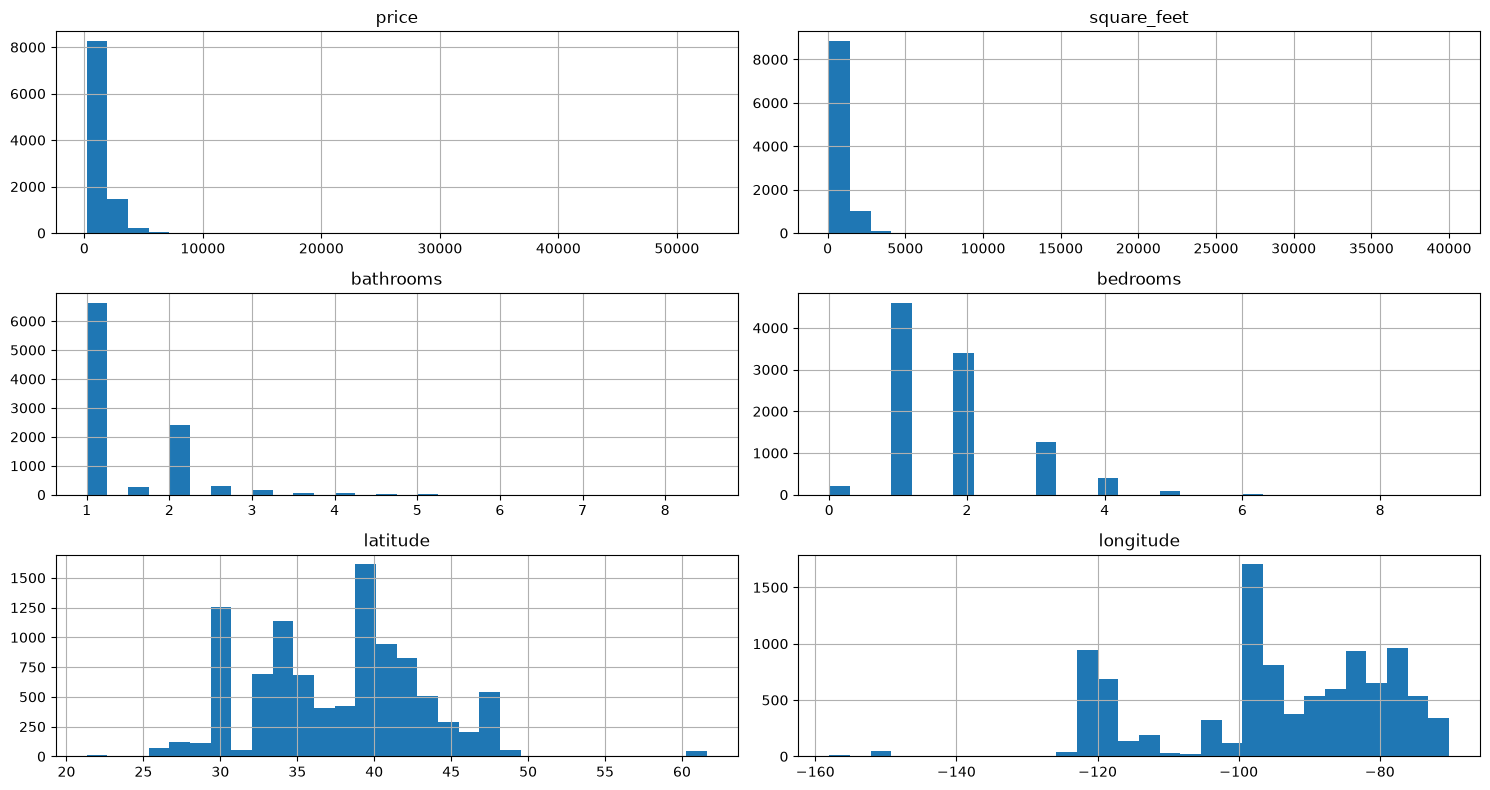

In [8]:
# Basic distributions of the main numerical variables in the RAW data.
# price and square_feet are especially important for checking right-skewness.
eda_numeric_cols = ['price', 'square_feet', 'bathrooms', 'bedrooms', 'latitude', 'longitude']

data[eda_numeric_cols].hist(figsize=(15, 8), bins=30)
plt.tight_layout()
plt.show()


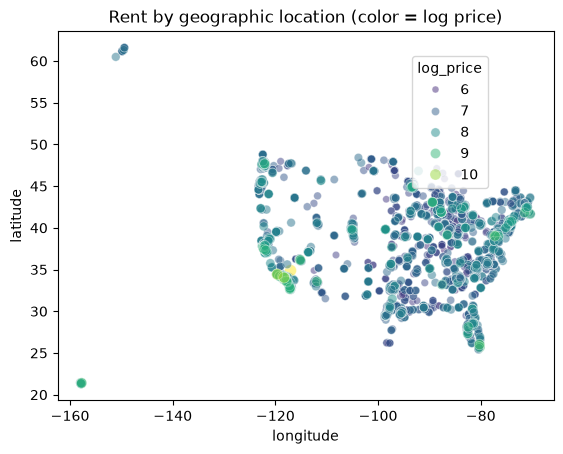

In [9]:
# Geographic EDA: point color and size represent the logarithm of price.
# The log is used only to make the visualization easier to read; the raw data is not modified here.
eda_map = data[['longitude', 'latitude', 'price']].dropna().copy()
eda_map = eda_map[eda_map['price'] > 0]
eda_map['log_price_eda'] = np.log(eda_map['price'])

sns.scatterplot(
    data=eda_map,
    x='longitude',
    y='latitude',
    size='log_price_eda',
    hue='log_price_eda',
    palette='viridis',
    alpha=0.5,
)
plt.legend(title='log_price', bbox_to_anchor=(0.7, 0.95), loc='upper left')
plt.title('Rent by geographic location (color = log price)');


In [10]:
# Missing values in the original data.
# We do NOT perform imputation here yet; it will be done after the train/test split inside the pipeline,
# preventing data leakage from the test set into the training set.
data.isna().sum().sort_values(ascending=False).head(15)


pets_allowed    4163
amenities       3549
address         3327
cityname          77
state             77
bathrooms         34
latitude          10
longitude         10
bedrooms           7
category           0
title              0
body               0
id                 0
fee                0
price_type         0
dtype: int64

# Data Preprocessing

After EDA, individual variables are transformed into a form suitable for modeling.

An important principle: **transformations that learn from the data (such as imputation, TargetEncoder, or scaling) must not be fitted on the entire dataset before the train/test split.** These steps are therefore placed later inside the pipeline and are learned only from the training data.


## Transforming Individual Columns

### `amenities`

`amenities` contains a comma-separated list of apartment features.

In this reference solution, a simple representation is used: **the number of listed amenities** (`n_amenities`).

Advantage:
- fast solution with almost no increase in dimensionality.

Disadvantage:
- the model does not distinguish *which* amenities are present; for example, a refrigerator may not have the same effect on rent as a swimming pool, tennis court, or hot tub.

An alternative would be to create a separate 0/1 dummy (multi-hot) variable for each amenity type.


In [11]:
# Simple representation of amenities: number of comma-separated items.
# A missing value is interpreted here as 0 listed amenities.
# Alternative: multi-hot/dummy columns for each individual amenity type.
data['amenities_list'] = data['amenities'].str.split(',')
data.loc[data['amenities_list'].isnull(), 'amenities_list'] = ''
data['n_amenities'] = data['amenities_list'].apply(len)


### `pets_allowed`

Similar to `amenities`, the text list is converted into the **number of allowed pet types**:

- nothing listed → 0,
- dog or cat → 1,
- both → 2.

This is a simple numerical representation. However, the difference between values 1 and 2 does not necessarily have a linear economic effect on rent.


In [12]:
# Convert pets_allowed to the number of allowed pet types.
# Nothing listed -> 0, one type -> 1, both types -> 2.
data['pets_allowed_list'] = data['pets_allowed'].str.split(',')
data.loc[data['pets_allowed_list'].isnull(), 'pets_allowed_list'] = ''
data['pets_allowed_int'] = data['pets_allowed_list'].apply(len)


### `price_type` / `price`

First, `value_counts()` is used to inspect which price types occur in the dataset.

Weekly and monthly prices must be converted to the **same time period**. Otherwise, a few weekly observations could look like extremely cheap apartments and materially worsen both the model error and $R^2$.

The reference solution converts `Weekly` and `Monthly|Weekly` observations to an approximate monthly price by multiplying by 4. Although there are only a few such records, it is useful to make the preprocessing robust to a future expansion of the dataset.


In [13]:
data['price_type'].value_counts()

price_type
Monthly           9998
Weekly               1
Monthly|Weekly       1
Name: count, dtype: int64

In [14]:
data[['price_type', 'price']].sort_values('price_type', ascending=False).head(5)

,price_type,price
15,Weekly,1560
235,Monthly|Weekly,275
0,Monthly,790
1,Monthly,425
2,Monthly,1390


In [15]:
# Convert prices to an approximate monthly basis.
# Reference solution: Weekly / Monthly|Weekly -> price * 4.
# Reason: a different time basis would create artificial price outliers.
data.loc[data['price_type'].isin(['Monthly|Weekly', 'Weekly']), 'price'] = data['price'] * 4


### `has_photo`

The variable contains the values `Yes`, `No`, and `Thumbnail`.

The solution converts them into binary information:

- `Yes` or `Thumbnail` → 1,
- otherwise → 0.

The idea is that a photograph, or at least a thumbnail, may be related to the quality of presentation/marketing of the listing and therefore indirectly to rent.


In [16]:
data.has_photo.value_counts()

has_photo
Thumbnail    8907
Yes           909
No            184
Name: count, dtype: int64

In [17]:
# values 'Yes', 'Thumbnail' -> 1, otherwise 0
data['has_photo_int'] = 0
data.loc[data.has_photo.isin(['Yes', 'Thumbnail']), 'has_photo_int'] = 1

## Log Transformation

### Why log-transform `square_feet`

Apartment size typically has a right-skewed distribution: most apartments fall within a relatively common size range, while a small number of properties are extremely large. Taking the logarithm compresses extreme values and usually makes the distribution more symmetric.

### Why `price` is more complicated

`price` is the target variable. Modeling `log_price` can be beneficial, but the results must be interpreted carefully:

- the model is trained on `log_price`,
- if we want to evaluate prediction error in actual dollars, predictions must be transformed back using the exponential function,
- $R^2$ on `log_price` is **not the same** as $R^2$ on the original price scale.

We return to this distinction in the evaluation section.


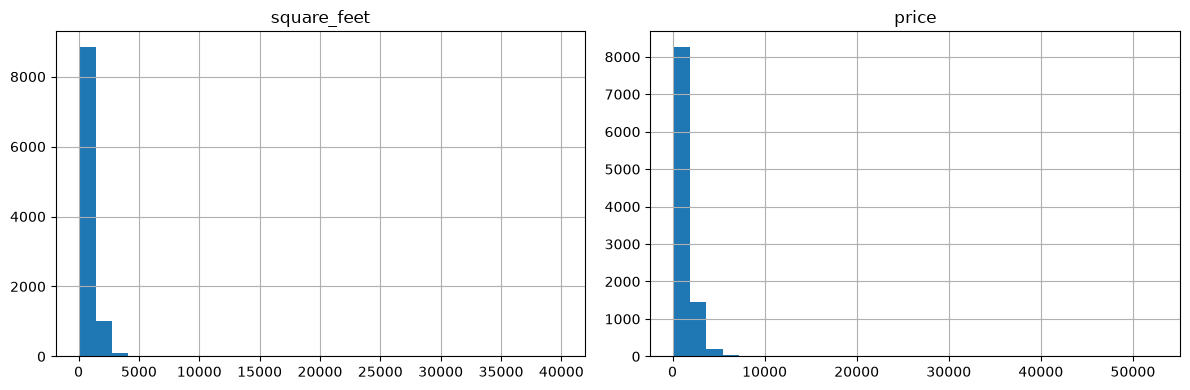

In [18]:
# display columns with skewed distributions
data[['square_feet', 'price']].hist(bins=30, figsize=(12, 4))
plt.tight_layout()
plt.show()

In [19]:
# Log-transform apartment size to compress the right tail of very large apartments.
data['log_square_feet'] = np.log(data['square_feet'])


In [20]:
# The target is modeled on a logarithmic scale.
# For business evaluation, predictions must be transformed back using exp().
data['log_price'] = np.log(data['price'])


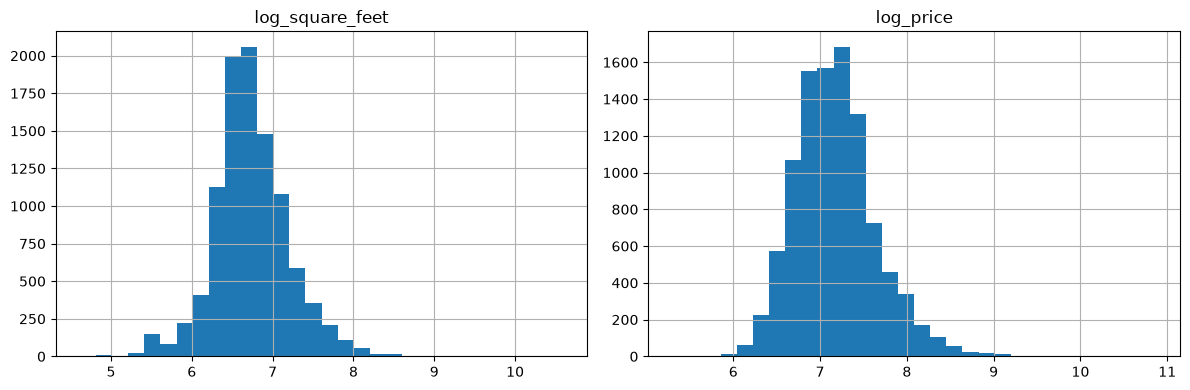

In [21]:
# after log transformation
data[['log_square_feet', 'log_price']].hist(bins=30, figsize=(12, 4), layout=(1, 2))

plt.tight_layout()
plt.show()

## Checking Values in the Remaining Columns

`value_counts()` is used as a quick diagnostic for categorical variables. It helps identify:

- almost constant columns,
- very rare categories,
- duplicated information,
- whether a variable makes sense for modeling.

In this solution, for example:
- `currency` is constant → drop,
- `fee` is constant → drop,
- `category` is almost constant → do not use,
- `price_display` duplicates `price` → do not use,
- `source` is retained because different listing websites may have different price compositions.


In [22]:
# (almost) constant values
data.category.value_counts()

category
housing/rent/apartment     9996
housing/rent/home             2
housing/rent/short_term       2
Name: count, dtype: int64

In [23]:
# constant values
data.currency.value_counts()

currency
USD    10000
Name: count, dtype: int64

In [24]:
# constant values
data.fee.value_counts()

fee
No    10000
Name: count, dtype: int64

In [25]:
# price_display - identical information to price
data[['price', 'price_display']].head()

,price,price_display
0,790,$790
1,425,$425
2,1390,"$1,390"
3,925,$925
4,880,$880


In [26]:
data.source.value_counts()

source
RentLingo            6912
RentDigs.com         2764
ListedBuy             179
RealRentals            69
GoSection8             31
Listanza               23
RENTOCULAR             16
rentbits                2
Home Rentals            1
Real Estate Agent       1
RENTCafé                1
tenantcloud             1
Name: count, dtype: int64

## Narrowing the Dataset to Relevant Columns

We create `data_narrow`: a dataset containing only the variables that will be used in further modeling.

The purpose is to:
- remove constant/almost constant information,
- remove duplicates and identifiers,
- exclude long text columns that are not processed further in this solution,
- retain `source`, because the listing source may contain useful price information.

This also makes the following pipeline easier to understand.


In [27]:
data.columns

Index(['id', 'category', 'title', 'body', 'amenities', 'bathrooms', 'bedrooms',
       'currency', 'fee', 'has_photo', 'pets_allowed', 'price',
       'price_display', 'price_type', 'square_feet', 'address', 'cityname',
       'state', 'latitude', 'longitude', 'source', 'time', 'amenities_list',
       'n_amenities', 'pets_allowed_list', 'pets_allowed_int', 'has_photo_int',
       'log_square_feet', 'log_price'],
      dtype='str')

### Overview of Removed and Retained Columns

**Removed due to (almost) constant values:**
- `fee` – practically no variability,
- `currency` – all prices are in USD,
- `category` – almost all observations are `housing`; a few rare values would add very little information here.

**Removed long text columns:**
- `title`,
- `body`.

NLP is not used in this reference solution, so these columns are not processed further.

**Removed for other reasons:**
- `id` – an identifier rather than an apartment characteristic,
- `price_display` – duplicates the target information in `price`,
- `time` – not used as a time feature in this solution.

**`source` is retained:** the source listing website may have a different mix of properties and prices and can therefore contain predictive information.


In [28]:
# Modeling dataset: selected relevant variables only.
# It excludes identifiers, redundant price_display, and long text fields.
data_narrow = data[[
    'log_price', 'bathrooms', 'bedrooms', 'log_square_feet',
    'cityname', 'state', 'latitude', 'longitude', 'source',
    'n_amenities', 'pets_allowed_int', 'has_photo_int'
]].copy()


## Missing-Value Analysis

At this stage, we only **identify** missing values and zeros.

A key principle of the project solution:

> Imputation is not performed on the complete dataset before the train/test split.

The imputer is fitted later inside the pipeline on the training portion only. Otherwise, information from the test set could indirectly influence the imputed values (**data leakage**).

A zero value does not automatically indicate an error – for example, `bedrooms=0` can represent a studio apartment. In a production project, suspicious zero values should ideally be verified against the source websites.


In [29]:
# will be imputed
data_narrow.isna().sum()

log_price            0
bathrooms           34
bedrooms             7
log_square_feet      0
cityname            77
state               77
latitude            10
longitude           10
source               0
n_amenities          0
pets_allowed_int     0
has_photo_int        0
dtype: int64

In [30]:
# zero values - zeros are acceptable in all columns shown here
# (e.g. bedrooms=0 is a valid value for a studio apartment)
(data_narrow == 0).sum()

log_price              0
bathrooms              0
bedrooms             198
log_square_feet        0
cityname               0
state                  0
latitude               0
longitude              0
source                 0
n_amenities         3549
pets_allowed_int    4163
has_photo_int        184
dtype: int64

## Squared Latitude and Longitude

Geographic EDA shows that rent is not a linear function of location: some areas (for example, parts of the coasts) have systematically higher prices.

We therefore add:
- `latitude_sq = latitude²`
- `longitude_sq = longitude²`

Later, `PolynomialFeatures` creates additional interactions. Because the squared geographic variables already exist, the model can also represent higher-order (3rd- and 4th-order) relationships and therefore more flexible curved relationships between location and rent.

These features could also be created inside the pipeline; here they are created beforehand mainly to simplify working with column names.


In [31]:
data_narrow['latitude_sq'] = data_narrow['latitude'] ** 2
data_narrow['longitude_sq'] = data_narrow['longitude'] ** 2

# Modeling

## Helper Functions

Two helper functions are used:

- `search_grid_and_print_score()` – performs hyperparameter search and prints CV/train/test scores,
- `print_scores()` – standardizes the comparison of multiple trained models.

> Note: despite the name `search_grid...`, the implementation uses **`RandomizedSearchCV`**, not `GridSearchCV`. It therefore evaluates a random number of parameter combinations (`n_iter`), which is faster when the search space contains many hyperparameters.


In [32]:
def search_grid_and_print_score(estimator, param_distributions, X_train, X_test, y_train, y_test, cv=5, n_iter=20):
    """Trains a model using RandomizedSearchCV, including hyperparameter search

    :param estimator: estimator or pipeline to train
    :param param_distributions: hyperparameter search space
    :param X_train:
    :param X_test:
    :param y_train:
    :param y_test:
    :param cv: parametr cv pro RandomizedSearchCV
    :param n_iter: parametr n_iter pro RandomizedSearchCV
    """
    # RandomizedSearchCV object
    search = RandomizedSearchCV(estimator=estimator, param_distributions=param_distributions, n_iter=n_iter, scoring='r2', 
                                   cv=cv, random_state=42, n_jobs=-1, verbose=3)
    
    # train model
    search.fit(X_train, y_train)

    # results
    print("Best Parameters:", search.best_params_)
    print("Best CV Score:", np.round(search.best_score_, 3))
    print(f"Train score: {np.round(search.score(X_train, y_train), 3)}")
    print(f"Test score: {np.round(search.score(X_test, y_test), 3)}")

    return search

In [33]:
def print_scores(models, labels, X_train, X_test, y_train, y_test):
    """Calculates scores for all models

    :param models: list of models
    :param labels: list of model names
    :param X_train:
    :param X_test:
    :param y_train:
    :param y_test:
    """
    scores_cv = []
    scores_train = []
    scores_test = []

    # iterate over each model
    for model in models:
        scores_cv.append(np.round(model.best_score_, 3))
        scores_train.append(np.round(model.score(X_train, y_train), 3))
        scores_test.append(np.round(model.score(X_test, y_test), 3))

    results = pd.DataFrame({
        'CV': scores_cv,
        'Train': scores_train,
        'Test': scores_test        
    }, index=labels)

    return results

## Train / Test Split

The data is divided into **75% training / 25% test** (`test_size=0.25`).

The test set is intended to simulate future, unseen data. Imputation, encoding, and scaling must therefore not be fitted on the test data – these steps are part of the pipeline and are learned only from the training portion.


In [34]:
X = data_narrow.copy().drop(columns='log_price')
y = data_narrow.log_price

In [35]:
# 75% train / 25% test.
# All data-learned transformations (encoding, imputation, scaling) are applied only inside the pipeline.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)


## Data Transformation Pipeline

Transformations are wrapped in a pipeline so that every step is learned only from the training data (and, during cross-validation, only from the corresponding training fold).

Order:

1. **Categorical encoding**
   - `cityname`, `state`, and `source` receive both Target Encoding and limited One-Hot Encoding.
   - `max_categories` limits the number of OHE columns; less frequent values are grouped into `infrequent`.
   - `max_categories` is itself a hyperparameter and can be optimized.

2. **KNN imputation**
   - performed after encoding because KNNImputer works with numerical values,
   - both the number of neighbors and the weighting method are included in the hyperparameter search.

3. **Polynomial / interaction features**
   - created only for selected variables to avoid uncontrolled growth in dimensionality.

4. **RobustScaler**
   - reduces the influence of extreme values,
   - scaling is especially important for regularized linear models such as LASSO.

`verbose_feature_names_out=False` shortens transformed feature names and makes them easier to use later.


In [36]:
X.columns

Index(['bathrooms', 'bedrooms', 'log_square_feet', 'cityname', 'state',
       'latitude', 'longitude', 'source', 'n_amenities', 'pets_allowed_int',
       'has_photo_int', 'latitude_sq', 'longitude_sq'],
      dtype='str')

In [37]:
# NEW: referencing transformed columns is simplified with verbose_feature_names_out=False; transformer prefixes are not added to column names.
# The same result is possible without this option, but we would need to determine the exact transformed column names.
cols_ohe = ['cityname', 'state']
cols_interactions = ['n_amenities', 'bathrooms', 'bedrooms', 'pets_allowed_int', 'log_square_feet', 'cityname', 'state', 'source', 'latitude', 'longitude', 'latitude_sq', 'longitude_sq']
cols_nan = ['bathrooms','bedrooms','latitude', 'latitude_sq', 'longitude', 'longitude_sq', 'cityname', 'state']

In [38]:
# Encode categorical variables.
#
# cityname + state:
#   - TargetEncoder captures the relationship with the target,
#   - OHE preserves information about the most frequent categories.
#
# source:
#   - same principle, but fewer OHE categories.
#
# max_categories limits dimensionality and groups less frequent values into 'infrequent'.
# max_categories is itself a hyperparameter and is tuned later.
encoder = make_column_transformer(
    (TargetEncoder(target_type='continuous'), cols_ohe),
    (OneHotEncoder(max_categories=5, handle_unknown='infrequent_if_exist', sparse_output=False), cols_ohe),

    (TargetEncoder(target_type='continuous'), ['source']),
    (OneHotEncoder(max_categories=3, handle_unknown='infrequent_if_exist', sparse_output=False), ['source']),

    remainder='passthrough',
    verbose_feature_names_out=False
).set_output(transform='pandas')


In [39]:
# KNN imputation of missing values.
# It runs after the train/test split and inside the pipeline -> no leakage from the test set.
# n_neighbors and weights are tuned as hyperparameters.
imputer = make_column_transformer(
    (KNNImputer(n_neighbors=5, weights='distance', add_indicator=False), cols_nan),
    remainder='passthrough',
    verbose_feature_names_out=False
).set_output(transform='pandas')


In [40]:
# Interactions only among selected variables.
# interaction_only=True does not directly create all squared terms,
# but because latitude_sq / longitude_sq already exist, it also creates combinations
# corresponding to higher-order terms and more complex geographic relationships.
interactions = make_column_transformer(
    (PolynomialFeatures(degree=2, interaction_only=True, include_bias=False), cols_interactions),
    remainder='passthrough',
    verbose_feature_names_out=False
).set_output(transform='pandas')


In [41]:
# Complete transformation pipeline.
# During CV, each step is fitted only on the training fold.
# RobustScaler is less sensitive to outliers and is especially important for LASSO.
pipe_transform = make_pipeline(
    encoder,
    imputer,
    interactions,
    RobustScaler().set_output(transform='pandas')
)


In [42]:
# Diagnostic preview of the preprocessing pipeline output only.
# It is fitted here on X_train, not on the complete dataset.
transformed_data = pipe_transform.fit_transform(X_train, y_train)


In [43]:
# display transformed data
transformed_data.head()

# Values can be negative because RobustScaler centers transformed features
# around their median. Negative bedrooms/bathrooms therefore do NOT represent
# negative physical values; they are scaled values used by the model.

,n_amenities,bathrooms,bedrooms,pets_allowed_int,log_square_feet,cityname,state,source,latitude,longitude,...,cityname_infrequent_sklearn,state_CA,state_NC,state_TX,state_WA,state_infrequent_sklearn,source_RentDigs.com,source_RentLingo,source_infrequent_sklearn,has_photo_int
4901,0.0,0.0,-1.0,0.0,-0.011843,0.537938,0.028850,0.043101,0.574750,0.224540,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4375,1.4,0.0,-1.0,-0.5,-0.109342,-0.267846,0.248404,-0.045676,0.817591,0.014863,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6698,0.2,0.0,0.0,-1.0,0.381650,-1.447335,-0.542140,1.003058,0.388740,0.519453,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-1.0,0.0,0.0
9805,-0.4,2.5,1.0,-1.0,2.143324,-0.248925,0.410347,-0.005227,-1.100968,0.624717,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1101,0.6,0.0,-1.0,-1.0,-0.845355,-0.324422,-0.341485,-0.045676,-1.100115,-0.205593,...,-1.0,0.0,0.0,1.0,0.0,-1.0,0.0,0.0,0.0,0.0


In [44]:
# transformed_data.columns

## Model 1 – Random Forest

Random Forest combines many decision trees and aggregates their predictions. It can naturally capture nonlinearities and interactions between features.

The hyperparameter search does not tune only the Random Forest model itself, but also parameters of the preceding transformation pipeline (such as `max_categories` or KNN imputation settings). This is important: **practically any parameter inside the pipeline can be treated as a hyperparameter.**

After training, the object is saved using `pickle` so that the computationally expensive search does not need to be repeated every time the notebook is opened.


In [45]:
# complete modeling pipeline
pipe_model_rf = make_pipeline(
    pipe_transform,
    RandomForestRegressor(random_state=42))

In [46]:
# pipe_model_rf.get_params()

### What Is Tuned for Random Forest

The search includes both **model hyperparameters** (`max_depth`, `n_estimators`, `max_features`, ...) and **preprocessing hyperparameters** (`max_categories`, `n_neighbors`, `weights`).

This is one of the main advantages of a pipeline: the complete preprocessing + model workflow can be optimized as a single unit.


In [47]:
param_grid_rf = {

    # Maximum number of categories kept by OneHotEncoder.
    # Less frequent categories are grouped into the "infrequent" category.
    # Higher values preserve more categorical detail but also increase dimensionality.
    'pipeline__columntransformer-1__onehotencoder-1__max_categories': [3, 5, 8],


    # Number of nearest observations used by KNNImputer
    # to estimate missing values.
    # Smaller values use more local information,
    # while larger values produce smoother imputations.
    'pipeline__columntransformer-2__knnimputer__n_neighbors': [5, 10, 20],


    # How neighboring observations contribute to KNN imputation:
    # - 'uniform': all selected neighbors have equal importance
    # - 'distance': closer neighbors receive higher weight
    'pipeline__columntransformer-2__knnimputer__weights': ['distance', 'uniform'],


    # Fraction of available features considered when searching
    # for the best split in each tree.
    # Example: 0.5 means that approximately 50% of features
    # are considered at each split.
    #
    # Lower values increase randomness between trees and may reduce overfitting.
    'randomforestregressor__max_features': [0.5, 0.6, 0.7],


    # Minimum number of observations that must remain
    # in a terminal leaf node.
    #
    # Higher values make trees more conservative / smoother
    # and can reduce overfitting.
    'randomforestregressor__min_samples_leaf': [1, 5, 8],


    # Maximum depth of each decision tree.
    #
    # None = no explicit depth limit;
    # the tree grows until another stopping condition is reached.
    #
    # Smaller values create simpler trees and stronger regularization.
    'randomforestregressor__max_depth': [None, 5, 10, 18],


    # Minimum number of observations required in a node
    # before the algorithm is allowed to split it.
    #
    # Higher values prevent splitting very small groups
    # and can therefore reduce overfitting.
    'randomforestregressor__min_samples_split': [2, 5, 9],


    # Number of decision trees in the Random Forest.
    #
    # More trees usually make the prediction more stable,
    # but also increase training and prediction time.
    'randomforestregressor__n_estimators': [80, 110, 140]
}

### Saving Trained Models (`pickle`)

Hyperparameter search can take a long time. The trained object is therefore saved using `pickle.dump()`.

- with `train_flag=True`, the model is trained and saved,
- with `train_flag=False`, it is loaded using `pickle.load()`.

This makes it possible to reopen the notebook and continue with evaluation without retraining the model.


In [48]:
if train_flag:
    # train model
    model_rf = search_grid_and_print_score(pipe_model_rf, param_grid_rf, X_train, X_test, y_train, y_test, n_iter=30)

    # save model
    with open(r'models\model_rf.pkl', 'wb') as f:
        pickle.dump(model_rf, f)
else:
    # load saved model
    with open(r'models\model_rf.pkl', 'rb') as f:
        model_rf = pickle.load(f)

## Model 2 – XGBRegressor

XGBoost is a gradient-boosting algorithm: trees are built sequentially and each new tree attempts to improve the errors of the previous trees.

As with Random Forest, we jointly optimize:
- preprocessing,
- number of trees,
- learning rate,
- tree depth,
- subsampling,
- feature sampling.

After training, the model is again saved using `pickle`.


In [49]:
# complete modeling pipeline
pipe_model_xgb = make_pipeline(
    pipe_transform,
    XGBRegressor(random_state=42))

In [50]:
# pipe_model_xgb.get_params()

### What Is Tuned for XGBoost

In addition to preprocessing parameters, we tune for example:

- `learning_rate` – step size contributed by each boosting tree,
- `n_estimators` – number of trees,
- `max_depth` – tree complexity,
- `subsample` – proportion of rows used for individual trees,
- `colsample_bytree` – proportion of features used for a tree.

The objective is not simply to maximize the training score, but to find the parameter combination with the strongest cross-validation $R^2$.


In [51]:
param_grid_xgb = {
    'pipeline__columntransformer-1__onehotencoder-1__max_categories': [3, 5, 8],
    'pipeline__columntransformer-2__knnimputer__n_neighbors': [5, 10, 20],
    'pipeline__columntransformer-2__knnimputer__weights': ['distance', 'uniform'],
    'xgbregressor__learning_rate': [0.05, 0.1, 0.2], 
    'xgbregressor__colsample_bytree':  [0.3,0.5,0.7],
    'xgbregressor__max_depth': [None, 5, 10, 15],
    'xgbregressor__subsample': [0.3, 0.5, 0.7],
    'xgbregressor__n_estimators': [100, 150, 200]
}

In [52]:
if train_flag:
    # train model
    model_xgb = search_grid_and_print_score(pipe_model_xgb, param_grid_xgb, X_train, X_test, y_train, y_test, n_iter=30)

    # save model
    with open(r'models\model_xgb.pkl', 'wb') as f:
        pickle.dump(model_xgb, f)
else:
    # load saved model
    with open(r'models\model_xgb.pkl', 'rb') as f:
        model_xgb = pickle.load(f)

## Model 3 – LASSO (Reference Model)

LASSO is a linear regression model with **L1 regularization**. It serves as a simpler reference model against the tree-based ensemble methods.

L1 regularization can shrink some coefficients all the way to zero, so it also acts as a form of feature selection. Because the penalty depends on coefficient magnitude, the input variables should be appropriately scaled – here this is handled by `RobustScaler`.

Tuning LASSO is substantially faster because it has fewer model-specific hyperparameters.


In [53]:
# complete modeling pipeline
pipe_model_lasso = make_pipeline(
    pipe_transform,
    Lasso()
)

In [54]:
#pipe_model_lasso.get_params()

### What Is Tuned for LASSO

LASSO has fewer model-specific hyperparameters; the main one is `alpha`, which controls the strength of L1 regularization.

Preprocessing is still tuned at the same time (for example, the number of OHE categories and KNN imputation settings), so even the simpler model receives a fairly optimized input.


In [55]:
param_grid_lasso = {
    'pipeline__columntransformer-1__onehotencoder-1__max_categories': [3, 5, 8],
    'pipeline__columntransformer-2__knnimputer__n_neighbors': [5, 10, 20],
    'pipeline__columntransformer-2__knnimputer__weights': ['distance', 'uniform'],
    'lasso__alpha': [0.005, 0.01, 0.05, 0.1]
}

In [56]:
if train_flag:
    # train model
    model_lasso = search_grid_and_print_score(pipe_model_lasso, param_grid_lasso, X_train, X_test, y_train, y_test, n_iter=30)

    # save model
    with open(r'models\model_lasso.pkl', 'wb') as f:
        pickle.dump(model_lasso, f)
else:
    # load saved model
    with open(r'models\model_lasso.pkl', 'rb') as f:
        model_lasso = pickle.load(f)

## Model 4 – Ridge (Reference Model)

LASSO is a linear regression model with **L1 regularization**. It serves as a simpler reference model against the tree-based ensemble methods.

L1 regularization can shrink some coefficients all the way to zero, so it also acts as a form of feature selection. Because the penalty depends on coefficient magnitude, the input variables should be appropriately scaled – here this is handled by `RobustScaler`.

Tuning LASSO is substantially faster because it has fewer model-specific hyperparameters.

Ridge is a linear regression model with **L2 regularization**. Like LASSO, it serves as a simpler reference model against the tree-based ensemble methods.

**L2 regularization penalizes large coefficient values and shrinks them toward zero, but unlike LASSO, it usually does not reduce coefficients exactly to zero. This means that Ridge typically keeps all features in the model while reducing their individual influence.**

Ridge can be particularly useful when several predictors are correlated, because the model can distribute their contribution across multiple related variables instead of selecting only some of them. As with LASSO, appropriate feature scaling is important because the regularization penalty depends on coefficient magnitude. Here, scaling is handled by `RobustScaler`.

Ridge also has relatively few model-specific hyperparameters. The main parameter is alpha, which controls the strength of L2 regularization, so hyperparameter tuning is substantially faster than for the tree-based ensemble models.


In [57]:
# complete modeling pipeline
pipe_model_ridge = make_pipeline(
    pipe_transform,
    Ridge()
)

In [58]:
#pipe_model_ridge.get_params()

### What Is Tuned for Ridge

Ridge has fewer model-specific hyperparameters; the main one is `alpha`, which controls the strength of **L2 regularization**.

A higher `alpha` applies stronger regularization and shrinks the model coefficients more strongly toward zero, while a lower alpha allows the model to fit the training data more freely.

Preprocessing is still tuned at the same time — for example, the number of OHE categories and the KNN imputation settings — so the Ridge model is evaluated within the same optimized preprocessing framework as the other models.

In [59]:
param_grid_ridge = {
    'pipeline__columntransformer-1__onehotencoder-1__max_categories': [3, 5, 8],
    'pipeline__columntransformer-2__knnimputer__n_neighbors': [5, 10, 20],
    'pipeline__columntransformer-2__knnimputer__weights': ['distance', 'uniform'],
    'ridge__alpha': [0.01, 0.1, 1, 10, 100]
}

In [60]:
if train_flag:
    # train model
    model_ridge = search_grid_and_print_score(pipe_model_ridge, param_grid_ridge, X_train, X_test, y_train, y_test, n_iter=30)

    # save model
    with open(r'models\model_ridge.pkl', 'wb') as f:
        pickle.dump(model_ridge, f)
else:
    # load saved model
    with open(r'models\model_ridge.pkl', 'rb') as f:
        model_ridge = pickle.load(f)

In this project, the comparison is especially relevant because the preprocessing pipeline generates many transformed and potentially correlated features, including one-hot encoded variables, interaction terms, and geographic features. Comparing Ridge and LASSO therefore helps evaluate whether retaining correlated information improves the performance of the linear benchmark.

# Evaluation

First, the models are compared on the `log_price` target because this is the target on which they were trained.

The best model is then also evaluated after converting predictions back to the **actual rent** scale. This is essential: a strong $R^2$ on log-transformed rent does not necessarily imply an equally strong $R^2$ in dollars.


## Model Comparison

We compare:

- the best cross-validation score from hyperparameter search,
- the score on the full training set,
- the score on the test set.

A large difference between train and test scores may indicate overfitting. Cross-validation is the most important criterion for hyperparameter selection; the test set serves as the final check of generalization.


In [61]:
models = [
    model_rf,
    model_xgb,
    model_lasso,
    model_ridge
]

In [62]:
labels = [
    'random forest',
    'xgb',
    'lasso',
    'ridge'
]

In [63]:
print_scores(models, labels, X_train, X_test, y_train, y_test)

,CV,Train,Test
random forest,0.752,0.885,0.758
xgb,0.766,0.858,0.767
lasso,0.679,0.734,0.680
ridge,0.696,0.747,0.693


## ShuffleSplit Cross-Validation of the Best Model

The best model (XGBoost) is checked once more using `ShuffleSplit`.

Unlike standard K-Fold cross-validation, `ShuffleSplit` repeatedly creates random train/validation splits. The mean and standard deviation of the scores provide an additional indication of how stable model performance is across different data splits.


In [64]:
from sklearn.model_selection import ShuffleSplit, cross_val_score

In [65]:
# get the best model
best_model = model_xgb.best_estimator_

In [66]:
# obtain cross-validation scores
cv_shs = ShuffleSplit(n_splits=5, test_size=0.3, random_state=0)
scores_shs = cross_val_score(best_model, X_train, y_train, cv=cv_shs)

In [67]:
scores_shs

array([0.74986994, 0.76321204, 0.74661795, 0.74659064, 0.74074457])

In [68]:
print(f'{scores_shs.mean():.3f} with a standard deviation of {scores_shs.std():.3f}')

0.749 with a standard deviation of 0.008


In [69]:
# best_model is the best estimator from the XGBoost search.
print(f"Test score XGBoost: {np.round(best_model.score(X_test, y_test), 3)}")


Test score XGBoost: 0.767


## Permutation Feature Importance

To better understand which input variables contribute most to the predictive
performance of the selected XGBoost pipeline, we use **permutation importance**.

The idea is simple:

1. evaluate the fitted model on the unchanged test set,
2. randomly shuffle one feature while leaving all other features unchanged,
3. calculate the model score again,
4. measure how much the R² score decreases,
5. repeat the shuffling several times and average the result.

If shuffling a feature causes a large drop in R², the model relies strongly on
the information contained in that feature. If the score changes only slightly,
the feature contributes less to predictive performance.

Permutation importance is calculated on **`X_test` and `y_test`**, so the
importance values describe the model's dependence on the variables when
predicting previously unseen observations.

> **Important:** permutation importance measures predictive importance, not
> causality. A highly important variable does not necessarily cause rent to
> increase or decrease.


In [70]:
# Calculate permutation importance on the held-out test set.
# Each feature is shuffled 10 times and the mean decrease in R²
# shows how strongly the fitted model depends on that feature.
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(
    best_model,
    X_test,
    y_test,
    scoring="r2",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

In [71]:
# Store the mean importance and its standard deviation for each
# original input feature, then rank features from most to least important.
feature_importance = pd.DataFrame({
    "feature": X_test.columns,
    "importance": perm_importance.importances_mean,
    "std": perm_importance.importances_std
})

feature_importance = (feature_importance.sort_values("importance", ascending=False))

feature_importance

,feature,importance,std
2,log_square_feet,0.330337,0.011967
4,state,0.245732,0.006413
3,cityname,0.152923,0.004132
0,bathrooms,0.042295,0.002810
6,longitude,0.036078,0.002684
12,longitude_sq,0.032815,0.002801
1,bedrooms,0.029325,0.001260
5,latitude,0.025808,0.002241
11,latitude_sq,0.023116,0.001650
8,n_amenities,0.008316,0.000913


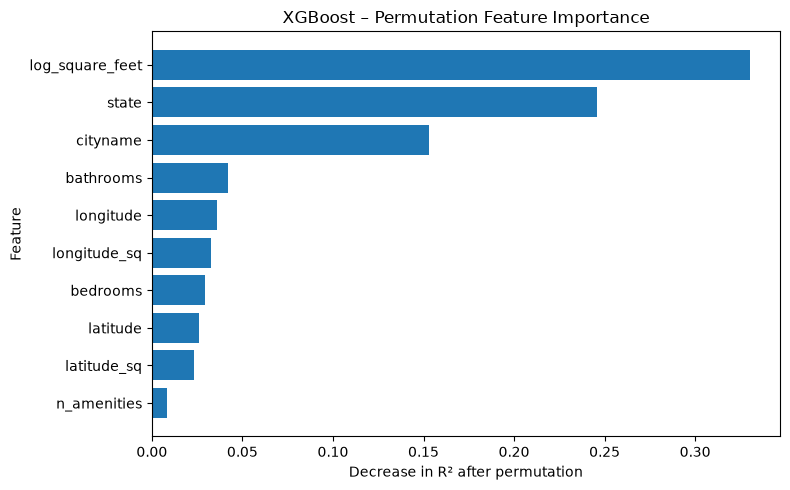

In [72]:
top_features = feature_importance.head(10).sort_values("importance")

plt.figure(figsize=(8, 5))

plt.barh(top_features["feature"], top_features["importance"])

plt.xlabel("Decrease in R² after permutation")
plt.ylabel("Feature")
plt.title("XGBoost – Permutation Feature Importance")

plt.tight_layout()
plt.show()

### Interpretation of the Feature Importance Results

The results show that **apartment size and location are the dominant sources of
predictive information** for the XGBoost model.

- **`log_square_feet`** is the most important feature. Shuffling it reduces R²
  by about **0.330** on average, indicating that apartment size is the single
  most important input for prediction.
- **`state`** is the second most important feature, with an average R² decrease
  of approximately **0.246**.
- **`cityname`** follows with an importance of approximately **0.153**.
  Together, `state` and `cityname` show that geographic location contains a
  large amount of information about rental prices.
- **`bathrooms`**, **`bedrooms`**, **`latitude`**, **`longitude`**, and their
  squared geographic terms contribute additional predictive information, but
  their individual effects are substantially smaller.
- **`n_amenities`**, **`source`**, and **`pets_allowed_int`** have relatively
  small permutation importance.
- **`has_photo_int`** has almost no effect on test-set R² in this model.

For example, an importance value of **0.330** for `log_square_feet` means that
randomly destroying the information in this feature decreases the model's R²
by roughly **0.33 points on average**. It does **not** mean that the feature
explains 33% of rent by itself.

These values should also be interpreted with some caution. When predictors are
correlated — for example `state`, `cityname`, `latitude`, and `longitude` —
their information can overlap. As a result, permutation importance may divide
predictive importance across several related variables.

Overall, the analysis suggests that the model relies primarily on
**property size and geographic location**, while listing metadata such as
photo availability or source contributes much less to predictive performance.


## Evaluating Error on `price` Instead of `log_price`

The model predicts `log_price`, but from a business perspective we are usually interested in the actual monthly rent.

Therefore:
1. predict `log_price`,
2. use `np.exp()` to transform both the target and prediction back to dollars,
3. calculate $R^2$ again on the original price scale.

The solution shows a substantial drop in $R^2$ after returning to the original price scale. The main reason is very expensive outliers: because $R^2$ is based on squared errors, a few extreme misses can strongly reduce the metric.

For diagnostic purposes, the result is then examined after excluding the top 2% of prices (98th percentile). **This is not automatically the correct production approach** – whether the extreme segment may be excluded is a business decision and must be explicitly disclosed when reporting the results.


In [73]:
y_pred_test = best_model.predict(X_test)

In [74]:
# R² score on the test set for log_price
r2_score(y_test, y_pred_test)

0.7667955826919824

In [75]:
# R² on the original price scale.
# np.exp() is the inverse transformation of log() used to create log_price.
r2_score(np.exp(y_test), np.exp(y_pred_test))


0.3662207785078909

In [76]:
# Outlier diagnostics: cutoff for the top 2% of the target.
# Note: y_test is log_price, so the percentile is defined on the log scale here.
# Removing these observations is an analytical experiment, not an automatic rule.
pct98 = np.percentile(y_test, 98)
pct98


np.float64(8.292798858200374)

In [77]:
# R² on the original price scale after excluding the top 2% of prices.
# This result should always be reported together with the fact that extreme values were filtered out.
hi_prices_mask = y_test > pct98
r2_score(
    np.exp(y_test[~hi_prices_mask]),
    np.exp(y_pred_test[~hi_prices_mask])
)


0.738699490014415

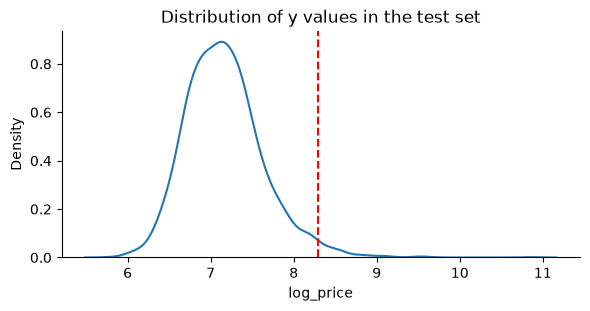

In [78]:
sns.displot(x=y_test, kind='kde', height=3, aspect=2, bw_adjust=1)
plt.axvline(x=pct98, linestyle='--', color='red')
plt.title('Distribution of y values in the test set');

plt.savefig('figures/log_price_distribution_EN.png', dpi=150, bbox_inches='tight')

# The same effect is visible in the log_price distribution plot:
# the far-right tail of the distribution is the part being excluded.

In [79]:
r2_score(
    np.exp(y_test[~hi_prices_mask]),
    np.exp(y_pred_test[~hi_prices_mask]))

0.738699490014415

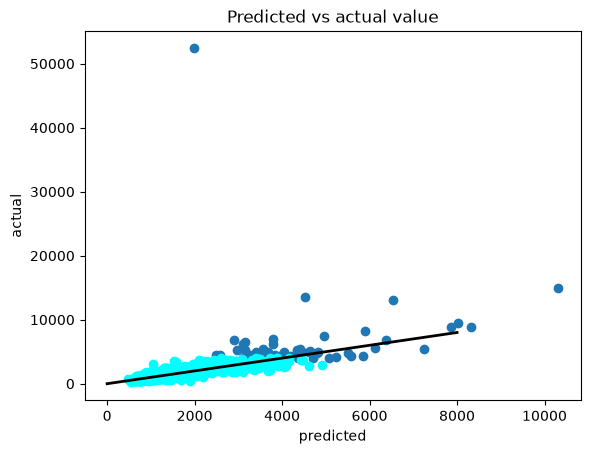

In [80]:
plt.scatter(np.exp(y_pred_test[hi_prices_mask]), np.exp(y_test[hi_prices_mask]))
plt.scatter(np.exp(y_pred_test[~hi_prices_mask]), np.exp(y_test[~hi_prices_mask]), c='cyan')
plt.plot([0, 8000], [0, 8000], color = 'black', linewidth = 2)
plt.xlabel('predicted')
plt.ylabel('actual')
plt.title('Predicted vs actual value');

plt.savefig('figures/predicted_vs_actual_EN.png', dpi=150, bbox_inches='tight')

# The same effect is shown again in the predicted-vs-actual plot.
# The horizontal axis contains predicted values and the vertical axis contains
# actual values. One especially extreme observation is clearly visible.
#
# R² is directly related to prediction errors, and those errors enter the
# calculation in squared form. Therefore, even a single very large miss can
# contribute disproportionately to the overall error.
#
# This extreme observation, together with several other high-price cases,
# explains why R² on the non-log-transformed price is substantially lower.
# The diagnostic experiment excludes the top 2% of target values (shown in
# blue). Once these extreme cases are removed, the model's R² improves
# considerably. This remains a diagnostic experiment rather than an automatic
# production rule.
